# Lab 1

## Introduction

### Tasks
1. Task 1. Using the file with song Essentia descriptors (GenreAll file), your aim is to train a
model with the highest accuracy possible. Explore different machine learning algorithms
(e.g, Logistic regression, k-NN, decision trees, ANN, and ensemble methods). Check for
overfitting and, if necessary, perform feature selection and tune the algorithm’s
parameters. Evaluate the model using 10-fold cross-validation.
2. Task 2. Same as Task 1, but this time using the features provided in the CSV files
features_30_sec.csv and features_3_sec.csv.

## Imports

In [ ]:
import os
from google.colab import drive
from google.colab import files
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import RFECV
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_validate, StratifiedKFold, StratifiedGroupKFold
from sklearn.decomposition import PCA

# Metrics
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import make_scorer
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_curve, roc_auc_score

# Models
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier

In [ ]:
# Constants
RANDOM_SEED = 42 # To reproduce same results
K_FOLD_SPLITS = 10

## Data Importing

In [ ]:
if not os.path.isdir("/content/drive"):
  drive.mount('/content/drive')

In [ ]:
try:
  df = pd.read_csv('/content/drive/MyDrive/MLSM/Lab1/GenreAll.csv', skipinitialspace = True)
except FileNotFoundError:
  uploaded = files.upload()
  df = pd.read_csv(list(uploaded.keys())[0], skipinitialspace = True)
except Exception as e:
  print(f"An error occurred: {e}")
  df = None

if df is not None:
    print(df['genre'].head())

0    blu
1    blu
2    blu
3    blu
4    blu
Name: genre, dtype: object


## Data Preprocessing

In [ ]:
# Check the dimensions of the problem
classes = df['genre'].unique().size
num_features = df.loc[:, df.columns != 'genre'].columns.size
classes, num_features

(10, 240)

In [ ]:
# Split in features and labels
X = df.loc[:, df.columns != 'genre']
y = df['genre']
X.shape, y.shape

((993, 240), (993,))

### One-Hot Encoding

In [ ]:
X.dtypes.value_counts()

,count
float64,235
object,3
int64,2


We have 3 features that are categorical, and if we analyze them we see that they only have 2 categories per feature and they do not follow any order, therefore a simple one hot encoding serves to numerate them.

In [ ]:
object_columns = X.select_dtypes('object')
print(object_columns.nunique())
X = pd.get_dummies(X, columns=list(object_columns), dtype=int)

highlevel_speech_music_value          2
highlevel_voice_instrumental_value    2
tonal_key_mode_value                  2
dtype: int64


### Identifying Outliers

In [ ]:
X.isnull().sum().unique()

array([0])

In [ ]:
X.describe()

,highlevel_danceability_value,highlevel_equalization_profile_value,highlevel_excitement_value,highlevel_intensity_value,loudness_dynamic_complexity_dvar,loudness_dynamic_complexity_mean,loudness_dynamic_complexity_var,loudness_larm_dvar,loudness_larm_mean,loudness_larm_var,...,tonal_dissonance_mean,tonal_dissonance_var,tonal_key_strength_value,tonal_tuning_equal_tempered_deviation_value,highlevel_speech_music_value_music,highlevel_speech_music_value_speech,highlevel_voice_instrumental_value_instrumental,highlevel_voice_instrumental_value_voice,tonal_key_mode_value_major,tonal_key_mode_value_minor
count,9.930000e+02,9.930000e+02,9.930000e+02,9.930000e+02,9.930000e+02,9.930000e+02,9.930000e+02,9.930000e+02,9.930000e+02,9.930000e+02,...,9.930000e+02,9.930000e+02,9.930000e+02,9.930000e+02,993.000000,993.000000,993.000000,993.000000,993.000000,993.000000
mean,1.409869e-08,-2.426989e-07,-1.903323e-07,-2.849950e-07,-8.056395e-09,4.028197e-09,-9.063444e-09,-9.063444e-09,1.007049e-09,1.007049e-09,...,1.208459e-08,5.035247e-09,-1.007049e-08,-1.107754e-08,0.733132,0.266868,0.416918,0.583082,0.700906,0.299094
std,1.000000e+00,1.000000e+00,9.999998e-01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,...,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.442546,0.442546,0.493298,0.493298,0.458092,0.458092
min,-1.749979e+00,-1.940715e+00,-1.283803e+00,-2.033312e+00,-1.544697e+00,-2.358412e+00,-1.920794e+00,-8.692910e-01,-4.734653e+00,-5.543780e-01,...,-3.951246e+00,-1.360556e+00,-3.888748e+00,-1.261447e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-6.782180e-01,3.727660e-01,-1.283803e+00,-6.154200e-01,-5.260830e-01,-6.626680e-01,-3.801670e-01,-4.762840e-01,-4.582420e-01,-3.020780e-01,...,-5.152250e-01,-7.031930e-01,-5.801600e-01,-7.311620e-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,-1.343310e-01,3.727660e-01,2.908700e-02,9.352600e-02,-1.408360e-01,-6.337200e-02,-1.661800e-02,-2.195150e-01,1.613420e-01,-2.195630e-01,...,2.499620e-01,-1.828180e-01,1.210030e-01,-2.326440e-01,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000
75%,5.040690e-01,3.727660e-01,1.341977e+00,8.024730e-01,2.549800e-01,5.346660e-01,2.732480e-01,1.984290e-01,6.010320e-01,-3.895800e-02,...,6.891900e-01,4.795720e-01,7.570800e-01,4.146560e-01,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,7.754278e+00,1.529507e+00,1.341977e+00,2.929312e+00,8.877894e+00,5.779127e+00,6.720551e+00,2.219928e+01,3.042905e+00,2.541121e+01,...,1.583319e+00,5.060315e+00,1.658376e+00,4.236572e+00,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Since there are too many features to visually analyze using graphs to detect outliers, I will use the IRQ filter to detect outliers for all categories, and anything that falls outside the Q1 or Q3 values ​​will be capped at these limits.

In [ ]:
def cap_outliers_iqr(X: pd.DataFrame) -> pd.DataFrame:
    """
    Applies the 1.5 * IQR (Interquartile Range) capping method to limit
    outliers in every column of the input DataFrame.

    Values beyond the defined limits are replaced by the limits themselves.

    Args:
        X (pd.DataFrame): The feature DataFrame to be cleaned.

    Returns:
        pd.DataFrame: A new DataFrame with outliers capped.
    """
    # Start the cleaning process on a copy of the features to avoid modifying the original data
    X_clean = X.copy()

    # Outliers capped using the 1.5*IQR method.
    for feature in X_clean.columns:

        # Calculate Q1 (25th percentile) and Q3 (75th percentile)
        Q1 = X_clean[feature].quantile(0.25)
        Q3 = X_clean[feature].quantile(0.75)
        IQR = Q3 - Q1

        # Define the Outlier Boundaries (1.5 * IQR)
        lower_limit = Q1 - 1.5 * IQR
        upper_limit = Q3 + 1.5 * IQR

        # Replace values above the upper limit with the upper limit
        X_clean[feature] = np.where(
            X_clean[feature] > upper_limit,
            upper_limit,
            X_clean[feature]
        )

        # Replace values below the lower limit with the lower limit
        X_clean[feature] = np.where(
            X_clean[feature] < lower_limit,
            lower_limit,
            X_clean[feature]
        )

    return X_clean

### Dimensional Reduction

https://scikit-learn.org/stable/modules/feature_selection.html

Given the imbalance between sample size (n≈1000) and feature count (p≈240), the model is highly prone to overfitting. Feature selection or extraction is required to reduce the degrees of freedom and establish a robust model with adequate predictive reliability.

#### Feature Selection

##### Filter Methods

I included the option of manual filtering with Weka methods.

In [ ]:
# Weka feature selection (hardcoded)
# CFS: Correlation-based Feature Selection
cfs_subset_bestfirst_eval = np.array([7,8,9,13,14,16,17,18,25,37,65,94,96,97,103,111,113,138,139,150,153,154,155,156,158,159,162,168,172,182,183,184,185,186,188,189,191,209,211,213,217,221,223,224,227,229,231,232,233,235,236,239]) - 1
cfs_subset_greedy_eval = np.array([8,9,13,14,16,17,18,25,37,65,94,96,97,103,111,138,139,150,153,154,155,156,158,159,162,168,172,182,183,184,185,186,188,189,191,209,211,213,217,221,223,227,229,231,232,233,235,236,239]) - 1
X_cfs_bestfirst = df.iloc[:, cfs_subset_bestfirst_eval]
X_cfs_greedy = df.iloc[:, cfs_subset_greedy_eval]

##### Wrapper Methods

Recursive feature elimination with cross-validation

In [ ]:
def perform_rfecv_feature_selection(X: pd.DataFrame, y: pd.Series, random_seed: int, scoring_metric: str = 'accuracy') -> pd.DataFrame:
    """
    Performs Recursive Feature Elimination with Cross-Validation (RFECV)
    to find the optimal subset of features that maximizes the scoring metric.

    Args:
        X (pd.DataFrame): The feature DataFrame (assumed to be already cleaned/imputed).
        y (pd.Series): The target variable.
        random_seed (int): Seed for reproducibility.
        scoring_metric (str): The metric to optimize (e.g., 'accuracy', 'f1_weighted').

    Returns:
        pd.DataFrame: A new DataFrame (X_final) containing only the optimal features.
    """

    # 1. Scaling the data (RFECV with LR requires scaled features)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # 2. Estimator: Using Logistic Regression for stability and speed.
    estimator = LogisticRegression(solver='liblinear', random_state=random_seed)

    # 3. Cross-Validation Strategy
    cv_strategy = StratifiedKFold(5, shuffle=True, random_state=random_seed)

    # 4. RFECV Setup
    rfecv = RFECV(
        estimator=estimator,
        step=1, # Eliminate 1 feature in each iteration
        cv=cv_strategy,
        scoring=scoring_metric,
        n_jobs=-1
    )

    # Fit RFECV to the scaled data
    print("Starting RFECV... (This may take a few moments depending on feature count)")
    rfecv.fit(X_scaled, y)

    cv_scores = rfecv.cv_results_['mean_test_score']
    optimal_score = np.max(cv_scores)
    optimal_n_features = rfecv.n_features_

    print("-" * 50)
    print(f"Optimal number of features found: {optimal_n_features}")
    print(f"Optimal CV score ({scoring_metric}): {optimal_score:.4f}")
    print("-" * 50)

    # 5. Result Visualization
    plt.figure(figsize=(10, 6))
    plt.title('RFECV: Score vs Number of Features')
    plt.xlabel("Number of Features Eliminated (from max)")
    plt.ylabel(f"Cross-Validation Score ({scoring_metric.capitalize()})")
    plt.plot(range(1, len(cv_scores) + 1), cv_scores)
    plt.axvline(x=len(cv_scores) - optimal_n_features + 1, color='r', linestyle='--', label='Optimal Feature Count')
    plt.legend()
    plt.grid(True)
    plt.show()


    # 6. New Dataset with Optimal Features
    optimal_features_mask = rfecv.support_
    X_final_feature_names = X.columns[optimal_features_mask]

    X_final = X[X_final_feature_names].copy() # Use .copy() for best practice

    print(f"\nFinal selected features ({X_final.shape[1]}): {X_final_feature_names.tolist()}")
    print(f"Dimensions of the final dataset: {X_final.shape}")

    return X_final

##### Embedded Methods

In [ ]:
def select_top_n_features_by_rf_importance(
    X_initial: pd.DataFrame,
    y: pd.Series,
    n_features: int,
    random_seed: int,
    test_size: float = 0.2
) -> pd.DataFrame:
    """
    Selects the top N features based on the importance score derived from a
    Random Forest Classifier trained on a subset of the data.

    Args:
        X_initial (pd.DataFrame): The current feature set (e.g., post-RFECV).
        y (pd.Series): The target variable.
        n_features (int): The desired number of top features to select.
        random_seed (int): Seed for reproducibility.
        test_size (float): Proportion of data to use for the test set (for splitting the ranking data).

    Returns:
        pd.DataFrame: A new DataFrame containing only the top N selected features.
    """

    # 1. Split the data to train the RF ranking model (80% for training)
    # We only split X_initial and y for the purpose of getting the ranking;
    # the test set here is just held out from the ranking process.
    X_train, X_test, y_train, y_test = train_test_split(
        X_initial, y, test_size=test_size, random_state=random_seed
    )

    # 2. Retrain an RF only for the importance ranking
    rf_ranking = RandomForestClassifier(
        n_estimators=100,
        random_state=random_seed,
        n_jobs=-1
    )
    print("Starting Random Forest fit for feature importance ranking...")
    rf_ranking.fit(X_train, y_train)

    # 3. Create a Series with the importance of all features and sort them
    importance = pd.Series(rf_ranking.feature_importances_, index=X_train.columns)
    sorted_importance = importance.sort_values(ascending=False)

    # 4. Select the Top N features
    N_FINAL_FEATURES = n_features
    features_top_N = sorted_importance.head(N_FINAL_FEATURES).index.tolist()

    print("-" * 50)
    print(f"Original features count: {X_initial.shape[1]}")
    print(f"Forced features (Top {N_FINAL_FEATURES}) selected.")
    print("-" * 50)

    # 5. Create the new, forcibly reduced dataset
    X_final_reduced = X_initial[features_top_N].copy()

    return X_final_reduced

#### Feature Extraction

##### PCA

In [ ]:
def perform_pca_variance_selection(
    X: pd.DataFrame,
    y: pd.Series,
    variance_threshold: float = 0.90
):
    """
    Performs PCA, calculates the number of components needed to retain a
    specified amount of variance, and returns the reduced DataFrame.

    Args:
        X (pd.DataFrame): The feature DataFrame.
        y (pd.Series): The target variable (used for LabelEncoding if needed).
        variance_threshold (float): The desired percentage of variance to retain (e.g., 0.90 for 90%).

    Returns:
        Tuple[pd.DataFrame, int]: A tuple containing the PCA-transformed DataFrame (X_pca)
                                   and the optimal number of components used.
    """

    # 1. Standardize the data
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Note: LabelEncoder for 'y' is included here mainly for the original script structure,
    # but PCA only needs X.
    # y_encoded = LabelEncoder().fit_transform(y)

    # 2. PCA to obtain all components and explained variance
    pca_full = PCA()
    pca_full.fit(X_scaled)

    explained_variance_ratio = pca_full.explained_variance_ratio_
    cumulative_variance_ratio = np.cumsum(explained_variance_ratio)

    # 3. Find the optimal number of components
    # np.argmax returns the index of the first value that meets the threshold
    # Add 1 because NumPy indices start at 0
    num_components_optimal = np.argmax(cumulative_variance_ratio >= variance_threshold) + 1

    # Check if the threshold is impossible to reach (i.e., argmax returned 0 and we added 1)
    if num_components_optimal == 1 and cumulative_variance_ratio[-1] < variance_threshold:
        num_components_optimal = pca_full.n_components_ # Use all if threshold is too high

    print("-" * 60)
    print(f"Variance Threshold: {variance_threshold*100:.0f}%")
    print(f"Optimal number of components: {num_components_optimal}")
    print("-" * 60)

    # 4. Plot the cumulative variance
    plt.figure(figsize=(8, 6))
    plt.plot(range(1, len(cumulative_variance_ratio) + 1), cumulative_variance_ratio, marker='o', linestyle='-')
    plt.xlabel('Number of Principal Components')
    plt.ylabel('Cumulative Explained Variance')
    plt.title('Cumulative Explained Variance vs. Number of Principal Components')
    plt.axvline(x=num_components_optimal, color='r', linestyle='--', label=f'{num_components_optimal} Components')
    plt.legend()
    plt.grid(True)
    plt.show()

    # 5. Apply PCA with the optimal number of components
    pca = PCA(n_components=num_components_optimal)
    X_pca_array = pca.fit_transform(X_scaled)

    # Convert the resulting NumPy array back to a DataFrame for consistency
    X_pca = pd.DataFrame(
        X_pca_array,
        columns=[f'PC_{i+1}' for i in range(num_components_optimal)]
    )

    print(f"Dimensions of the PCA-reduced dataset: {X_pca.shape}")

    return X_pca

## Models

Medir tiempo para comparar full (essentia) vs 30 vs 3. Se asimila la capacidad de analizar humana, o de RT.

Para las de 3 segundos, tal vez no hace falta hacer feature selection, para las demás si.



Mirar paper, tiene accuracy de aprox 61%

### Pipeline

In [ ]:
models_to_evaluate = {
    # Linear/Simple
    'Logistic Regression': LogisticRegression(solver='lbfgs', max_iter=1000,random_state=RANDOM_SEED, n_jobs=-1),
    'K-Nearest Neighbors': KNeighborsClassifier(),

    # Tree-Based
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_SEED),

    # Ensemble Methods
    #'Random Forest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1), # GridSearch for params?
    'Extra Trees (ETC)': ExtraTreesClassifier(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1), # ETC!
    #'AdaBoost': AdaBoostClassifier(random_state=RANDOM_SEED, estimator=DecisionTreeClassifier(max_depth=1)), # Bad Performance

    # Complex/Kernel-Based (expensives)
    #'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_SEED),
    #'XGBoost': XGBClassifier(use_label_encoder=True, eval_metric='mlogloss', random_state=RANDOM_SEED, n_jobs=-1),
    #'SVC (Linear)': SVC(random_state=RANDOM_SEED, probability=True),
    #'SVC (RBF Kernel)': SVC(random_state=RANDOM_SEED, probability=True),
    'ANN (MLP)': MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=RANDOM_SEED, early_stopping=True) # En principio solo ANN de scratch, no transfer learning, (si da tiempo probar).
}

In [ ]:
param_grids = {
    # Linear / Regularized Models
    'Logistic Regression': {
        # C (Inverse of regularization strength): Testing lower values is key to reduce overfitting
        'classifier__C': [0.001, 0.01, 0.1, 1, 10],
        'classifier__penalty': ['l2']
    },
    'K-Nearest Neighbors': {
        'classifier__n_neighbors': [3, 5, 10, 15],
        'classifier__weights': ['uniform', 'distance']
    },

    # === Support Vector Classifier (SVC) ===
    'SVC (Linear)': {
        'classifier__kernel': ['linear'],
        # C is the main control for regularization in linear SVC
        'classifier__C': [0.01, 0.1, 1, 10]
    },
    'SVC (RBF Kernel)': {
        'classifier__kernel': ['rbf'],
        # C (Regularization) and gamma (Kernel width/influence of a single point)
        'classifier__C': [0.1, 1, 10],
        'classifier__gamma': ['scale', 0.01, 0.1]
    },

    # Tree-Based Models (Strict pruning to control the ~7% Overfitting)
    'Decision Tree': {
        'classifier__max_depth': [3, 5, 8], # Limited depth is crucial
        'classifier__min_samples_leaf': [5, 10, 20] # Prevent deep, noisy splits
    },
    'Random Forest': {
        'classifier__n_estimators': [100, 300],
        'classifier__max_depth': [5, 10],
        'classifier__min_samples_leaf': [5, 10]
    },
    'Extra Trees Classifier': {
        'classifier__n_estimators': [100, 300],
        'classifier__max_depth': [5, 10],
        'classifier__min_samples_leaf': [5, 10]
    },

    # Neural Networks (ANN)
    'ANN (MLP)': {
        'classifier__hidden_layer_sizes': [(50,), (100,), (50, 20)],
        'classifier__alpha': [0.0001, 0.001, 0.01] # L2 Regularization
    }
}

In [ ]:
def tune_and_evaluate_models(X_train, y_train, X_test, y_test, models_dict, param_grids):
    """
    Automates model tuning (GridSearchCV) and evaluation, including the Train Score
    for comprehensive overfitting diagnosis.

    Args:
        X_train (pd.DataFrame or np.array): Training/Validation features.
        y_train (pd.Series or np.array): Training/Validation target.
        X_test (pd.DataFrame or np.array): Holdout Test features.
        y_test (pd.Series or np.array): Holdout Test target.
        models_dict (dict): Dictionary mapping model names to estimator objects.
        param_grids (dict): Dictionary mapping model names to their hyperparameter grids.

    Returns:
        pd.DataFrame: A comparison table including Train, CV Test, and Final Test Accuracies.
    """

    results = []
    cv_strategy = StratifiedKFold(n_splits=K_FOLD_SPLITS, shuffle=True, random_state=RANDOM_SEED)
    scoring_metric = 'accuracy' # ['accuracy', 'f1_weighted', 'roc_auc_ovr']

    print(f"--- MODEL | Final Test Accuracy | Overfitting Gap (CV Train Mean - CV Test Mean) ---\n")
    # Automatization Loop
    for name, estimator in models_dict.items():
        print(f"--- Evaluating and Tuning: {name} ---", end='')

        # Base Pipeline
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('classifier', estimator)
        ])

        # Inicializar variables
        mean_train_acc = np.nan
        mean_cv_test_acc = np.nan
        final_pipeline = pipeline
        best_params = 'Default'

        # GridSearchCV
        if name in param_grids and param_grids[name]:
            # Starting GridSearchCV

            grid_search = GridSearchCV(
                pipeline,
                param_grid=param_grids[name],
                cv=cv_strategy,
                scoring=scoring_metric,
                n_jobs=-1,
                return_train_score=True # Show memorization metric
            )

            grid_search.fit(X_train, y_train)

            # Pick best model score (train)
            best_index = grid_search.cv_results_['rank_test_score'].argmin()

            mean_train_acc = grid_search.cv_results_['mean_train_score'][best_index]
            mean_cv_test_acc = grid_search.best_score_
            final_pipeline = grid_search.best_estimator_
            best_params = grid_search.best_params_

            # Best params found: {best_params}

        else:
            # Running with default parameters (No Grid Search).
            cv_scores = cross_validate(
                pipeline, X_train, y_train,
                cv=cv_strategy, scoring=scoring_metric,
                n_jobs=-1, return_train_score=True
            )
            final_pipeline.fit(X_train, y_train)
            mean_train_acc = cv_scores['train_score'].mean()
            mean_cv_test_acc = cv_scores['test_score'].mean()

        # Test eval
        y_pred_test = final_pipeline.predict(X_test)
        final_test_accuracy = accuracy_score(y_test, y_pred_test)

        # Overfitting Gap
        overfitting_gap = (mean_train_acc - mean_cv_test_acc) * 100

        print(f"  Acc: {final_test_accuracy:.4f} |", end="")
        print(f"  OF Gap: {overfitting_gap:.2f}%")

        # Save Results
        results.append({
            'Model': name,
            'Optimal Hyperparams': best_params,
            'CV Mean Train Acc': mean_train_acc,
            'CV Mean Test Acc': mean_cv_test_acc,
            'Overfitting Gap (%)': overfitting_gap,
            'Final Test Accuracy': final_test_accuracy
        })

    comparison_df = pd.DataFrame(results).sort_values(by='Final Test Accuracy', ascending=False)
    return comparison_df

### Essentia Dataset

In [ ]:
y = LabelEncoder().fit_transform(y)

In [ ]:
# Split data in train & test
# X: DataFrame with all features.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED)

print(f"Total dataset size: {X.shape}")

results_0 = tune_and_evaluate_models(X_train, y_train, X_test, y_test, models_to_evaluate, param_grids)

Total dataset size: (993, 243)
--- MODEL | Final Test Accuracy | Overfitting Gap (CV Train Mean - CV Test Mean) ---

--- Evaluating and Tuning: Logistic Regression ---  Acc: 0.8141 |  OF Gap: 16.88%
--- Evaluating and Tuning: K-Nearest Neighbors ---  Acc: 0.7688 |  OF Gap: 27.46%
--- Evaluating and Tuning: Decision Tree ---  Acc: 0.5930 |  OF Gap: 15.36%
--- Evaluating and Tuning: Random Forest ---  Acc: 0.8141 |  OF Gap: 19.35%
--- Evaluating and Tuning: Extra Trees (ETC) ---  Acc: 0.8291 |  OF Gap: 21.91%
--- Evaluating and Tuning: SVC (Linear) ---  Acc: 0.8090 |  OF Gap: 13.50%
--- Evaluating and Tuning: SVC (RBF Kernel) ---  Acc: 0.8392 |  OF Gap: 20.79%
--- Evaluating and Tuning: ANN (MLP) ---  Acc: 0.7437 |  OF Gap: 15.10%


In [ ]:
# Split data in train & test
# X_clean: DataFrame with all features IRQ capped.

X_clean = cap_outliers_iqr(X)
X_train, X_test, y_train, y_test = train_test_split(X_clean, y, test_size=0.2, random_state=RANDOM_SEED)

print(f"Total dataset size: {X_clean.shape}")

results_1 = tune_and_evaluate_models(X_train, y_train, X_test, y_test, models_to_evaluate, param_grids)

Total dataset size: (993, 243)
--- MODEL | Final Test Accuracy | Overfitting Gap (CV Train Mean - CV Test Mean) ---

--- Evaluating and Tuning: Logistic Regression ---  Acc: 0.8342 |  OF Gap: 15.51%
--- Evaluating and Tuning: K-Nearest Neighbors ---  Acc: 0.7940 |  OF Gap: 27.58%
--- Evaluating and Tuning: Decision Tree ---  Acc: 0.5930 |  OF Gap: 15.03%
--- Evaluating and Tuning: Random Forest ---  Acc: 0.8191 |  OF Gap: 18.61%
--- Evaluating and Tuning: Extra Trees (ETC) ---  Acc: 0.8241 |  OF Gap: 20.52%
--- Evaluating and Tuning: SVC (Linear) ---  Acc: 0.8342 |  OF Gap: 12.33%
--- Evaluating and Tuning: SVC (RBF Kernel) ---  Acc: 0.8643 |  OF Gap: 17.64%
--- Evaluating and Tuning: ANN (MLP) ---  Acc: 0.7688 |  OF Gap: 15.99%


Starting RFECV... (This may take a few moments depending on feature count)
--------------------------------------------------
Optimal number of features found: 67
Optimal CV score (accuracy): 0.8509
--------------------------------------------------


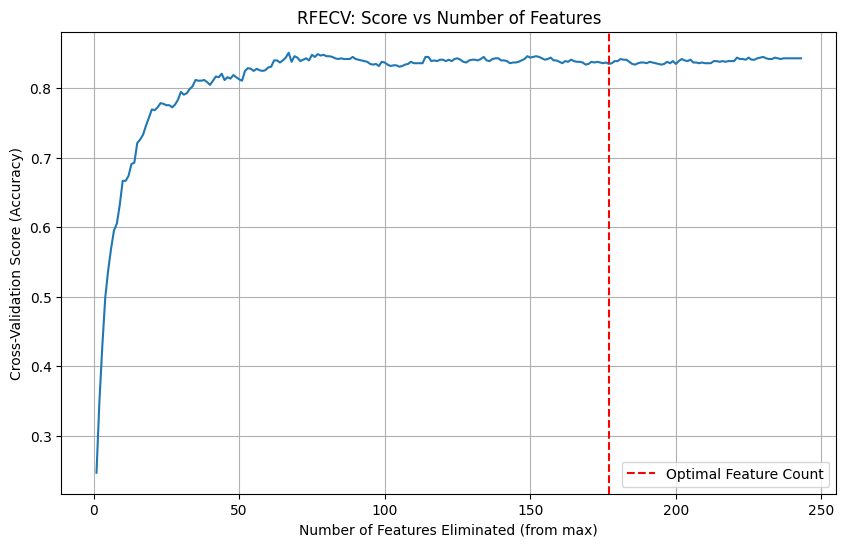


Final selected features (67): ['loudness_larm_mean', 'loudness_replay_gain_value', 'loudness_vicker_dvar', 'loudness_vicker_var', 'rhythm_beats_loudness_bass_mean', 'rhythm_onset_rate_value', 'spectral_barkbands_00_mean', 'spectral_barkbands_01_mean', 'spectral_barkbands_02_dvar', 'spectral_barkbands_03_mean', 'spectral_barkbands_18_mean', 'spectral_barkbands_18_var', 'spectral_barkbands_21_mean', 'spectral_barkbands_22_mean', 'spectral_barkbands_23_dvar', 'spectral_barkbands_23_mean', 'spectral_barkbands_24_mean', 'spectral_barkbands_kurtosis_mean', 'spectral_barkbands_skewness_dvar', 'spectral_barkbands_skewness_mean', 'spectral_barkbands_spread_dvar', 'spectral_barkbands_spread_var', 'spectral_centroid_dvar', 'spectral_crest_dvar', 'spectral_energy_dvar', 'spectral_energy_var', 'spectral_energybandratio_high_mean', 'spectral_energybandratio_low_dvar', 'spectral_energybandratio_middle_low_dvar', 'spectral_flatness_db_mean', 'spectral_flux_dvar', 'spectral_flux_mean', 'spectral_flux_

In [ ]:
# Split data in train & test
# X_final: DataFrame with optimal features (from RFECV).

X_final = perform_rfecv_feature_selection(cap_outliers_iqr(X), y, RANDOM_SEED)
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=RANDOM_SEED)

print(f"Total dataset size: {X_final.shape}")

results_2 = tune_and_evaluate_models(X_train, y_train, X_test, y_test, models_to_evaluate, param_grids)

In [ ]:
# Split data in train & test
# X_final_reduced: DataFrame with optimal features (RFECV + top 40ranking RF).

X_final_reduced = select_top_n_features_by_rf_importance(X_final, y, 40, RANDOM_SEED)
X_train, X_test, y_train, y_test = train_test_split(X_final_reduced, y, test_size=0.2, random_state=RANDOM_SEED)

print(f"Total dataset size: {X_final_reduced.shape}")

results_3 = tune_and_evaluate_models(X_train, y_train, X_test, y_test, models_to_evaluate, param_grids)

Starting Random Forest fit for feature importance ranking...
--------------------------------------------------
Original features count: 67
Forced features (Top 40) selected.
--------------------------------------------------
Total dataset size: (993, 40)
--- MODEL | Final Test Accuracy | Overfitting Gap (CV Train Mean - CV Test Mean) ---

--- Evaluating and Tuning: Logistic Regression ---  Acc: 0.8492 |  OF Gap: 11.66%
--- Evaluating and Tuning: K-Nearest Neighbors ---  Acc: 0.8392 |  OF Gap: 23.68%
--- Evaluating and Tuning: Decision Tree ---  Acc: 0.5829 |  OF Gap: 14.80%
--- Evaluating and Tuning: Random Forest ---  Acc: 0.7839 |  OF Gap: 17.40%
--- Evaluating and Tuning: Extra Trees (ETC) ---  Acc: 0.8392 |  OF Gap: 19.64%
--- Evaluating and Tuning: SVC (Linear) ---  Acc: 0.8643 |  OF Gap: 9.66%
--- Evaluating and Tuning: SVC (RBF Kernel) ---  Acc: 0.8693 |  OF Gap: 15.74%
--- Evaluating and Tuning: ANN (MLP) ---  Acc: 0.7889 |  OF Gap: 6.83%


------------------------------------------------------------
Variance Threshold: 90%
Optimal number of components: 45
------------------------------------------------------------


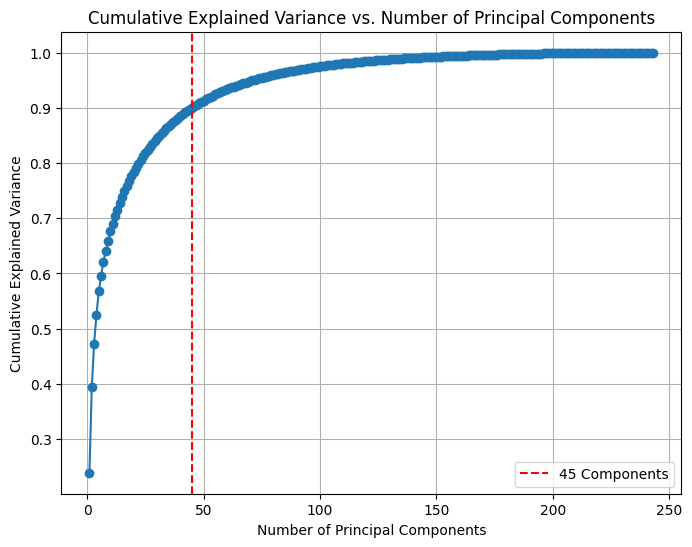

Dimensions of the PCA-reduced dataset: (993, 45)
Total dataset size: (993, 45)
--- MODEL | Final Test Accuracy | Overfitting Gap (CV Train Mean - CV Test Mean) ---

--- Evaluating and Tuning: Logistic Regression ---  Acc: 0.7789 |  OF Gap: 12.40%
--- Evaluating and Tuning: K-Nearest Neighbors ---  Acc: 0.6884 |  OF Gap: 36.27%
--- Evaluating and Tuning: Decision Tree ---  Acc: 0.5427 |  OF Gap: 24.76%
--- Evaluating and Tuning: Random Forest ---  Acc: 0.7839 |  OF Gap: 26.76%
--- Evaluating and Tuning: Extra Trees (ETC) ---  Acc: 0.7839 |  OF Gap: 24.68%
--- Evaluating and Tuning: SVC (Linear) ---  Acc: 0.7588 |  OF Gap: 17.14%
--- Evaluating and Tuning: SVC (RBF Kernel) ---  Acc: 0.8392 |  OF Gap: 18.63%
--- Evaluating and Tuning: ANN (MLP) ---  Acc: 0.7688 |  OF Gap: 18.20%


In [ ]:
# Split data in train & test
# X_pca: DataFrame with optimal features (PCA 90%).

X_pca = perform_pca_variance_selection(cap_outliers_iqr(X), y, 0.9)
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=RANDOM_SEED)

print(f"Total dataset size: {X_pca.shape}")

results_4 = tune_and_evaluate_models(X_train, y_train, X_test, y_test, models_to_evaluate, param_grids)

------------------------------------------------------------
Variance Threshold: 99%
Optimal number of components: 47
------------------------------------------------------------


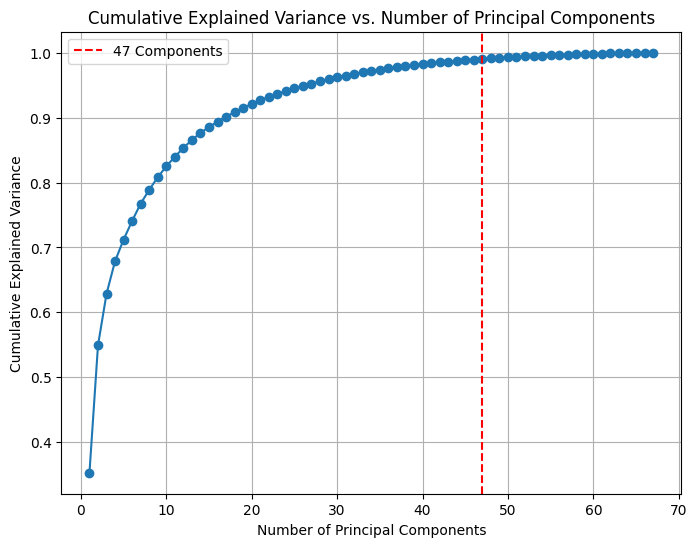

Dimensions of the PCA-reduced dataset: (993, 47)
Total dataset size: (993, 47)
--- MODEL | Final Test Accuracy | Overfitting Gap (CV Train Mean - CV Test Mean) ---

--- Evaluating and Tuning: Logistic Regression ---  Acc: 0.8543 |  OF Gap: 9.24%
--- Evaluating and Tuning: K-Nearest Neighbors ---  Acc: 0.6935 |  OF Gap: 31.74%
--- Evaluating and Tuning: Decision Tree ---  Acc: 0.5578 |  OF Gap: 23.62%
--- Evaluating and Tuning: Random Forest ---  Acc: 0.7789 |  OF Gap: 20.12%
--- Evaluating and Tuning: Extra Trees (ETC) ---  Acc: 0.8241 |  OF Gap: 19.76%
--- Evaluating and Tuning: SVC (Linear) ---  Acc: 0.8593 |  OF Gap: 7.99%
--- Evaluating and Tuning: SVC (RBF Kernel) ---  Acc: 0.8894 |  OF Gap: 10.46%
--- Evaluating and Tuning: ANN (MLP) ---  Acc: 0.7889 |  OF Gap: 13.13%


In [ ]:
# Split data in train & test
# X_pca: DataFrame with optimal features (RFECV + PCA 99%).

X_pca = perform_pca_variance_selection(X_final, y, 0.99)
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=RANDOM_SEED)

print(f"Total dataset size: {X_pca.shape}")

results_5 = tune_and_evaluate_models(X_train, y_train, X_test, y_test, models_to_evaluate, param_grids)

In [ ]:
# Split data in train & test
# X_cfs_bestfirst: DataFrame with optimal features (Weka cfs + bestfirst).

X_train, X_test, y_train, y_test = train_test_split(X_cfs_bestfirst, y, test_size=0.2, random_state=RANDOM_SEED)

print(f"Total dataset size: {X_cfs_bestfirst.shape}")

results_6 = tune_and_evaluate_models(X_train, y_train, X_test, y_test, models_to_evaluate, param_grids)

Total dataset size: (993, 52)
--- MODEL | Final Test Accuracy | Overfitting Gap (CV Train Mean - CV Test Mean) ---

--- Evaluating and Tuning: Logistic Regression ---  Acc: 0.8040 |  OF Gap: 15.59%
--- Evaluating and Tuning: K-Nearest Neighbors ---  Acc: 0.8141 |  OF Gap: 23.94%
--- Evaluating and Tuning: Decision Tree ---  Acc: 0.5678 |  OF Gap: 18.38%
--- Evaluating and Tuning: Random Forest ---  Acc: 0.8241 |  OF Gap: 17.06%
--- Evaluating and Tuning: Extra Trees (ETC) ---  Acc: 0.8392 |  OF Gap: 19.65%
--- Evaluating and Tuning: SVC (Linear) ---  Acc: 0.8291 |  OF Gap: 11.94%
--- Evaluating and Tuning: SVC (RBF Kernel) ---  Acc: 0.8442 |  OF Gap: 16.43%
--- Evaluating and Tuning: ANN (MLP) ---  Acc: 0.7789 |  OF Gap: 13.16%


In [ ]:
# Split data in train & test
# X_cfs_greedy: DataFrame with optimal features (Weka cfs + greedy).

X_train, X_test, y_train, y_test = train_test_split(X_cfs_greedy, y, test_size=0.2, random_state=RANDOM_SEED)

print(f"Total dataset size: {X_cfs_greedy.shape}")

results_7 = tune_and_evaluate_models(X_train, y_train, X_test, y_test, models_to_evaluate, param_grids)

Total dataset size: (993, 49)
--- MODEL | Final Test Accuracy | Overfitting Gap (CV Train Mean - CV Test Mean) ---

--- Evaluating and Tuning: Logistic Regression ---  Acc: 0.8191 |  OF Gap: 7.89%
--- Evaluating and Tuning: K-Nearest Neighbors ---  Acc: 0.8141 |  OF Gap: 22.79%
--- Evaluating and Tuning: Decision Tree ---  Acc: 0.5729 |  OF Gap: 18.37%
--- Evaluating and Tuning: Random Forest ---  Acc: 0.8141 |  OF Gap: 16.20%
--- Evaluating and Tuning: Extra Trees (ETC) ---  Acc: 0.8643 |  OF Gap: 17.64%
--- Evaluating and Tuning: SVC (Linear) ---  Acc: 0.8291 |  OF Gap: 11.13%
--- Evaluating and Tuning: SVC (RBF Kernel) ---  Acc: 0.8291 |  OF Gap: 15.74%
--- Evaluating and Tuning: ANN (MLP) ---  Acc: 0.7889 |  OF Gap: 9.74%


### Eval on Features 30 Seconds Dataset

In [ ]:
try:
  df_30 = pd.read_csv('/content/drive/MyDrive/MLSM/Lab1/features_30_sec.csv', skipinitialspace = True)
except FileNotFoundError:
  uploaded = files.upload()
  df_30 = pd.read_csv(list(uploaded.keys())[0], skipinitialspace = True)
except Exception as e:
  print(f"An error occurred: {e}")
  df_30 = None

if df_30 is not None:
    print(df_30['label'].head())

0    blues
1    blues
2    blues
3    blues
4    blues
Name: label, dtype: object


In [ ]:
# Split in features and labels
X_30 = df_30[df_30.columns.difference(['label', 'filename'])]
y_30 = df_30['label']
X_30.shape, y_30.shape

((1000, 58), (1000,))

In [ ]:
y_30 = LabelEncoder().fit_transform(y_30)

In [ ]:
# Split data in train & test
# X_30: DataFrame with all features.

X_train, X_test, y_train, y_test = train_test_split(X_30, y_30, test_size=0.2, random_state=RANDOM_SEED)

print(f"Total dataset size: {X_30.shape}")

results_30_0 = tune_and_evaluate_models(X_train, y_train, X_test, y_test, models_to_evaluate, param_grids)

Total dataset size: (1000, 58)
--- MODEL | Final Test Accuracy | Overfitting Gap (CV Train Mean - CV Test Mean) ---

--- Evaluating and Tuning: Logistic Regression ---  Acc: 0.7100 |  OF Gap: 21.00%
--- Evaluating and Tuning: K-Nearest Neighbors ---  Acc: 0.6900 |  OF Gap: 33.28%
--- Evaluating and Tuning: Decision Tree ---  Acc: 0.5750 |  OF Gap: 15.97%
--- Evaluating and Tuning: Random Forest ---  Acc: 0.7600 |  OF Gap: 21.31%
--- Evaluating and Tuning: Extra Trees (ETC) ---  Acc: 0.7900 |  OF Gap: 23.53%
--- Evaluating and Tuning: SVC (Linear) ---  Acc: 0.6950 |  OF Gap: 17.16%
--- Evaluating and Tuning: SVC (RBF Kernel) ---  Acc: 0.7300 |  OF Gap: 23.91%
--- Evaluating and Tuning: ANN (MLP) ---  Acc: 0.5500 |  OF Gap: 14.62%


In [ ]:
# Split data in train & test
# X_30_clean: DataFrame with all features cleaned.

X_30_clean = cap_outliers_iqr(X_30)
X_train, X_test, y_train, y_test = train_test_split(X_30_clean, y_30, test_size=0.2, random_state=RANDOM_SEED)

print(f"Total dataset size: {X_30_clean.shape}")

results_30_1 = tune_and_evaluate_models(X_train, y_train, X_test, y_test, models_to_evaluate, param_grids)

Total dataset size: (1000, 58)
--- MODEL | Final Test Accuracy | Overfitting Gap (CV Train Mean - CV Test Mean) ---

--- Evaluating and Tuning: Logistic Regression ---  Acc: 0.7400 |  OF Gap: 11.96%
--- Evaluating and Tuning: K-Nearest Neighbors ---  Acc: 0.7500 |  OF Gap: 26.01%
--- Evaluating and Tuning: Decision Tree ---  Acc: 0.5750 |  OF Gap: 14.22%
--- Evaluating and Tuning: Random Forest ---  Acc: 0.7500 |  OF Gap: 21.07%
--- Evaluating and Tuning: Extra Trees (ETC) ---  Acc: 0.8050 |  OF Gap: 20.89%
--- Evaluating and Tuning: SVC (Linear) ---  Acc: 0.7800 |  OF Gap: 14.01%
--- Evaluating and Tuning: SVC (RBF Kernel) ---  Acc: 0.7950 |  OF Gap: 18.08%
--- Evaluating and Tuning: ANN (MLP) ---  Acc: 0.7000 |  OF Gap: 11.38%


Starting RFECV... (This may take a few moments depending on feature count)
--------------------------------------------------
Optimal number of features found: 48
Optimal CV score (accuracy): 0.7400
--------------------------------------------------


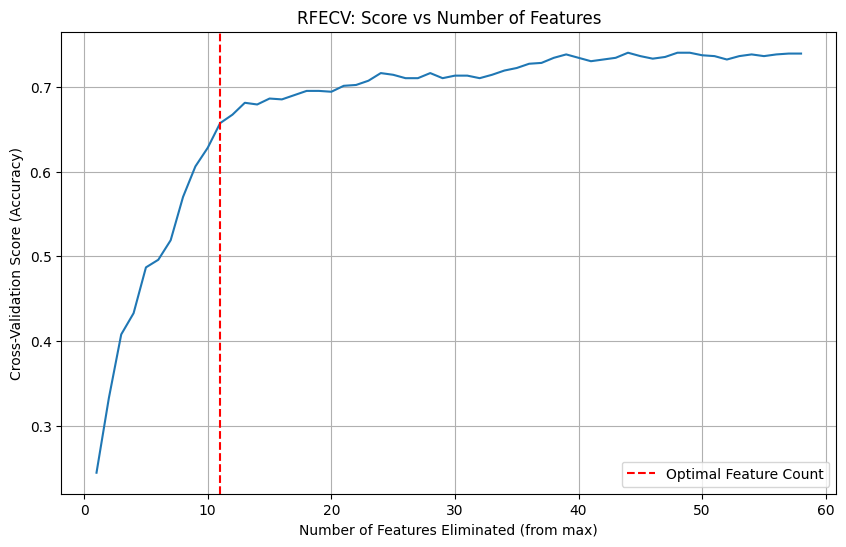


Final selected features (48): ['chroma_stft_mean', 'chroma_stft_var', 'harmony_mean', 'harmony_var', 'length', 'mfcc10_mean', 'mfcc10_var', 'mfcc11_mean', 'mfcc12_mean', 'mfcc13_var', 'mfcc15_mean', 'mfcc16_var', 'mfcc17_mean', 'mfcc17_var', 'mfcc18_mean', 'mfcc18_var', 'mfcc19_mean', 'mfcc19_var', 'mfcc1_mean', 'mfcc1_var', 'mfcc20_mean', 'mfcc20_var', 'mfcc2_mean', 'mfcc3_mean', 'mfcc3_var', 'mfcc4_mean', 'mfcc4_var', 'mfcc5_mean', 'mfcc5_var', 'mfcc6_mean', 'mfcc6_var', 'mfcc7_mean', 'mfcc7_var', 'mfcc8_mean', 'mfcc9_mean', 'mfcc9_var', 'perceptr_mean', 'perceptr_var', 'rms_mean', 'rms_var', 'rolloff_mean', 'rolloff_var', 'spectral_bandwidth_mean', 'spectral_bandwidth_var', 'spectral_centroid_mean', 'spectral_centroid_var', 'zero_crossing_rate_mean', 'zero_crossing_rate_var']
Dimensions of the final dataset: (1000, 48)
Total dataset size: (1000, 48)
--- MODEL | Final Test Accuracy | Overfitting Gap (CV Train Mean - CV Test Mean) ---

--- Evaluating and Tuning: Logistic Regression -

In [ ]:
# Split data in train & test
# X_30_final: DataFrame with optimal features (from RFECV).

X_30_final = perform_rfecv_feature_selection(cap_outliers_iqr(X_30), y_30, RANDOM_SEED)
X_train, X_test, y_train, y_test = train_test_split(X_30_final, y_30, test_size=0.2, random_state=RANDOM_SEED)

print(f"Total dataset size: {X_30_final.shape}")

results_30_2 = tune_and_evaluate_models(X_train, y_train, X_test, y_test, models_to_evaluate, param_grids)

In [ ]:
# Split data in train & test
# X_30_final_reduced: DataFrame with optimal features (RFECV + top 40ranking RF).

X_30_final_reduced = select_top_n_features_by_rf_importance(X_30_final, y_30, 40, RANDOM_SEED)
X_train, X_test, y_train, y_test = train_test_split(X_30_final_reduced, y_30, test_size=0.2, random_state=RANDOM_SEED)

print(f"Total dataset size: {X_30_final_reduced.shape}")

results_30_3 = tune_and_evaluate_models(X_train, y_train, X_test, y_test, models_to_evaluate, param_grids)

Starting Random Forest fit for feature importance ranking...
--------------------------------------------------
Original features count: 48
Forced features (Top 40) selected.
--------------------------------------------------
Total dataset size: (1000, 40)
--- MODEL | Final Test Accuracy | Overfitting Gap (CV Train Mean - CV Test Mean) ---

--- Evaluating and Tuning: Logistic Regression ---  Acc: 0.7200 |  OF Gap: 6.40%
--- Evaluating and Tuning: K-Nearest Neighbors ---  Acc: 0.7400 |  OF Gap: 24.64%
--- Evaluating and Tuning: Decision Tree ---  Acc: 0.5850 |  OF Gap: 14.60%
--- Evaluating and Tuning: Random Forest ---  Acc: 0.7200 |  OF Gap: 20.03%
--- Evaluating and Tuning: Extra Trees (ETC) ---  Acc: 0.7900 |  OF Gap: 19.39%
--- Evaluating and Tuning: SVC (Linear) ---  Acc: 0.7450 |  OF Gap: 10.53%
--- Evaluating and Tuning: SVC (RBF Kernel) ---  Acc: 0.7850 |  OF Gap: 15.99%
--- Evaluating and Tuning: ANN (MLP) ---  Acc: 0.7450 |  OF Gap: 10.00%


------------------------------------------------------------
Variance Threshold: 90%
Optimal number of components: 22
------------------------------------------------------------


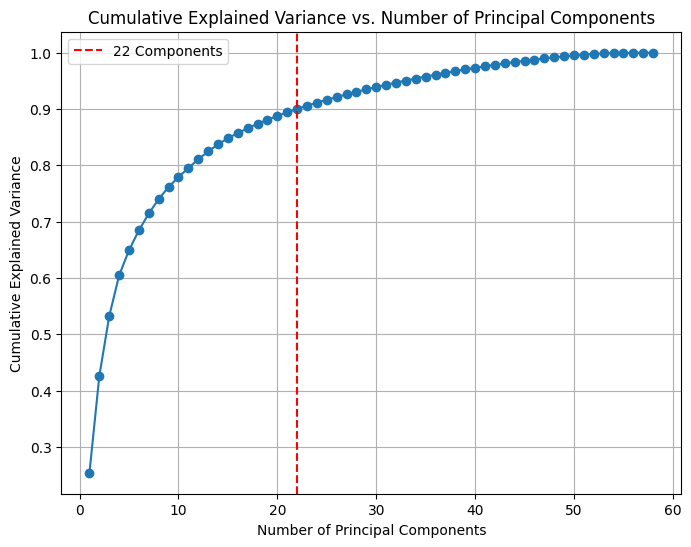

Dimensions of the PCA-reduced dataset: (1000, 22)
Total dataset size: (1000, 22)
--- MODEL | Final Test Accuracy | Overfitting Gap (CV Train Mean - CV Test Mean) ---

--- Evaluating and Tuning: Logistic Regression ---  Acc: 0.7000 |  OF Gap: 9.96%
--- Evaluating and Tuning: K-Nearest Neighbors ---  Acc: 0.6900 |  OF Gap: 28.39%
--- Evaluating and Tuning: Decision Tree ---  Acc: 0.4300 |  OF Gap: 18.64%
--- Evaluating and Tuning: Random Forest ---  Acc: 0.6650 |  OF Gap: 26.22%
--- Evaluating and Tuning: Extra Trees (ETC) ---  Acc: 0.7450 |  OF Gap: 24.01%
--- Evaluating and Tuning: SVC (Linear) ---  Acc: 0.7350 |  OF Gap: 9.61%
--- Evaluating and Tuning: SVC (RBF Kernel) ---  Acc: 0.7750 |  OF Gap: 20.64%
--- Evaluating and Tuning: ANN (MLP) ---  Acc: 0.7100 |  OF Gap: 10.35%


In [ ]:
# Split data in train & test
# X_30_pca: DataFrame with optimized features (PCA 90%).

X_30_pca = perform_pca_variance_selection(cap_outliers_iqr(X_30), y_30, 0.9)
X_train, X_test, y_train, y_test = train_test_split(X_30_pca, y_30, test_size=0.2, random_state=RANDOM_SEED)

print(f"Total dataset size: {X_30_pca.shape}")

results_30_4 = tune_and_evaluate_models(X_train, y_train, X_test, y_test, models_to_evaluate, param_grids)

------------------------------------------------------------
Variance Threshold: 99%
Optimal number of components: 39
------------------------------------------------------------


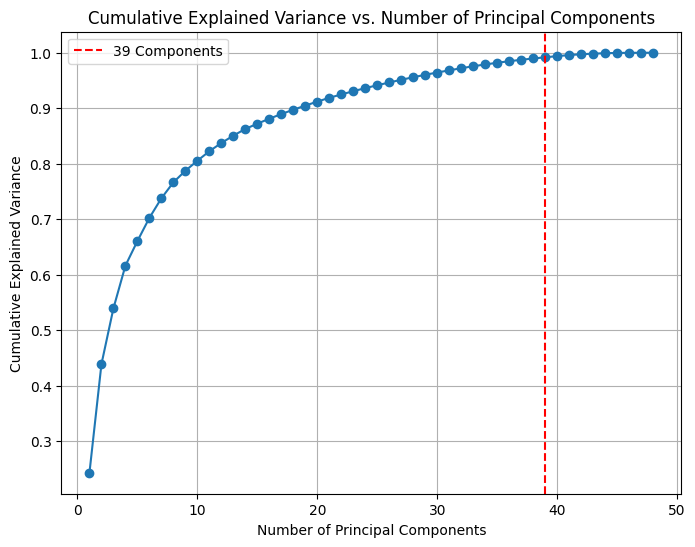

Dimensions of the PCA-reduced dataset: (1000, 39)
Total dataset size: (1000, 39)
--- MODEL | Final Test Accuracy | Overfitting Gap (CV Train Mean - CV Test Mean) ---

--- Evaluating and Tuning: Logistic Regression ---  Acc: 0.7250 |  OF Gap: 15.94%
--- Evaluating and Tuning: K-Nearest Neighbors ---  Acc: 0.7000 |  OF Gap: 32.39%
--- Evaluating and Tuning: Decision Tree ---  Acc: 0.4550 |  OF Gap: 20.86%
--- Evaluating and Tuning: Random Forest ---  Acc: 0.6800 |  OF Gap: 26.06%
--- Evaluating and Tuning: Extra Trees (ETC) ---  Acc: 0.7150 |  OF Gap: 24.01%
--- Evaluating and Tuning: SVC (Linear) ---  Acc: 0.7700 |  OF Gap: 16.43%
--- Evaluating and Tuning: SVC (RBF Kernel) ---  Acc: 0.8050 |  OF Gap: 22.39%
--- Evaluating and Tuning: ANN (MLP) ---  Acc: 0.7000 |  OF Gap: 16.79%


In [ ]:
# Split data in train & test
# X_30_pca: DataFrame with optimal features (RFECV + PCA 99%).

X_30_pca = perform_pca_variance_selection(X_30_final, y_30, 0.99)
X_train, X_test, y_train, y_test = train_test_split(X_30_pca, y_30, test_size=0.2, random_state=RANDOM_SEED)

print(f"Total dataset size: {X_30_pca.shape}")

results_30_5 = tune_and_evaluate_models(X_train, y_train, X_test, y_test, models_to_evaluate, param_grids)

### Eval on Features 3 Seconds Dataset

In [ ]:
try:
  df_3 = pd.read_csv('/content/drive/MyDrive/MLSM/Lab1/features_3_sec.csv', skipinitialspace = True)
except FileNotFoundError:
  uploaded = files.upload()
  df_3 = pd.read_csv(list(uploaded.keys())[0], skipinitialspace = True)
except Exception as e:
  print(f"An error occurred: {e}")
  df_3 = None

if df_3 is not None:
    print(df_3['label'].head())

0    blues
1    blues
2    blues
3    blues
4    blues
Name: label, dtype: object


In [ ]:
df_3['piece_id'] = df_3['filename'].apply(lambda x: ".".join(x.split(".")[:2]))

In [ ]:
# Separate features, labels, and groups
groups = df_3['piece_id']

# Define stratified group k-fold
sgkf = StratifiedGroupKFold(n_splits=K_FOLD_SPLITS, shuffle=True, random_state=RANDOM_SEED)

The stratifiedKFold already assumes there will be no overlap of labels in the Folds, so there is no need to use stratifiedGroupKFold

In [ ]:
# Split in features and labels
X_3 = df_3[df_3.columns.difference(['label', 'filename', 'length', 'piece_id'])]
y_3 = df_3['label']
X_3.shape, y_3.shape

((9990, 57), (9990,))

In [ ]:
y_3 = LabelEncoder().fit_transform(y_3)

In [ ]:
# Split data in train & test
# X_3: DataFrame with all features.

X_train, X_test, y_train, y_test = train_test_split(X_3, y_3, test_size=0.2, random_state=RANDOM_SEED)

print(f"Total dataset size: {X_3.shape}")

results_3_0 = tune_and_evaluate_models(X_train, y_train, X_test, y_test, models_to_evaluate, param_grids)

Total dataset size: (9990, 57)
--- MODEL | Final Test Accuracy | Overfitting Gap (CV Train Mean - CV Test Mean) ---

--- Evaluating and Tuning: Logistic Regression ---  Acc: 0.7362 |  OF Gap: 2.53%
--- Evaluating and Tuning: K-Nearest Neighbors ---  Acc: 0.9199 |  OF Gap: 10.12%
--- Evaluating and Tuning: Decision Tree ---  Acc: 0.5646 |  OF Gap: 6.43%
--- Evaluating and Tuning: Extra Trees (ETC) ---  Acc: 0.9014 |  OF Gap: 11.87%
--- Evaluating and Tuning: ANN (MLP) ---  Acc: 0.8438 |  OF Gap: 10.91%


In [ ]:
# Split data in train & test
# X_3_clean: DataFrame with all features cleaned.

X_train, X_test, y_train, y_test = train_test_split(cap_outliers_iqr(X_3), y_3, test_size=0.2, random_state=RANDOM_SEED)

print(f"Total dataset size: {X_3.shape}")

results_3_1 = tune_and_evaluate_models(X_train, y_train, X_test, y_test, models_to_evaluate, param_grids)

Total dataset size: (9990, 57)
--- MODEL | Final Test Accuracy | Overfitting Gap (CV Train Mean - CV Test Mean) ---

--- Evaluating and Tuning: Logistic Regression ---  Acc: 0.7382 |  OF Gap: 2.55%
--- Evaluating and Tuning: K-Nearest Neighbors ---  Acc: 0.9209 |  OF Gap: 9.47%
--- Evaluating and Tuning: Decision Tree ---  Acc: 0.5636 |  OF Gap: 6.54%
--- Evaluating and Tuning: Extra Trees (ETC) ---  Acc: 0.9034 |  OF Gap: 11.71%
--- Evaluating and Tuning: ANN (MLP) ---  Acc: 0.8493 |  OF Gap: 11.35%


------------------------------------------------------------
Variance Threshold: 90%
Optimal number of components: 30
------------------------------------------------------------


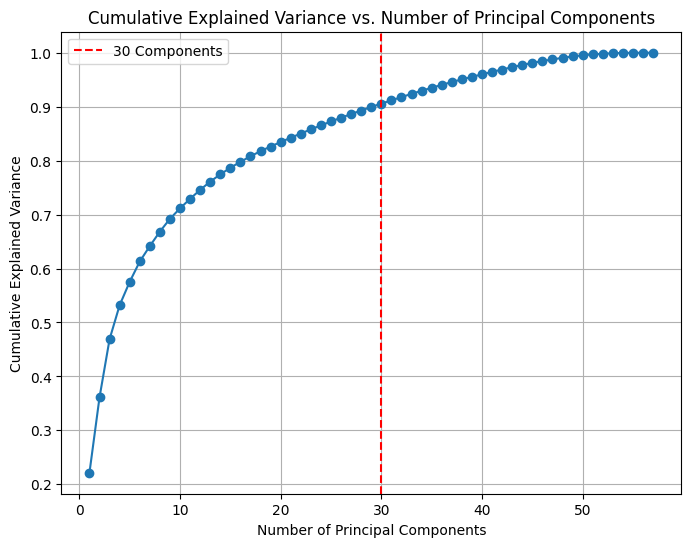

Dimensions of the PCA-reduced dataset: (9990, 30)
Total dataset size: (9990, 30)
--- MODEL | Final Test Accuracy | Overfitting Gap (CV Train Mean - CV Test Mean) ---

--- Evaluating and Tuning: Logistic Regression ---  Acc: 0.6682 |  OF Gap: 1.33%
--- Evaluating and Tuning: K-Nearest Neighbors ---  Acc: 0.8223 |  OF Gap: 20.20%
--- Evaluating and Tuning: Decision Tree ---  Acc: 0.5385 |  OF Gap: 10.04%
--- Evaluating and Tuning: Extra Trees (ETC) ---

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


  Acc: 0.8559 |  OF Gap: 17.08%
--- Evaluating and Tuning: ANN (MLP) ---  Acc: 0.7663 |  OF Gap: 10.12%


In [ ]:
# Split data in train & test
# X_3_pca: DataFrame with optimized features (PCA 90%).

X_3_pca = perform_pca_variance_selection(cap_outliers_iqr(X_3), y_3, 0.9)
X_train, X_test, y_train, y_test = train_test_split(X_3_pca, y_3, test_size=0.2, random_state=RANDOM_SEED)

print(f"Total dataset size: {X_3_pca.shape}")

results_3_2 = tune_and_evaluate_models(X_train, y_train, X_test, y_test, models_to_evaluate, param_grids)

## Evaluation

### Auxiliar Functions

In [ ]:
global_vars = globals()

list_of_dfs = []
experiment_names = []
# 1. Create the list of DataFrames (list_of_dfs)
for i in range(10):
    variable_name = f"results_{i}"

    # Check if the variable exists in the global namespace before trying to access it
    if variable_name in global_vars:
        df = global_vars[variable_name]

        # Critical Check: Ensure it's a DataFrame before appending
        if isinstance(df, pd.DataFrame):
            list_of_dfs.append(df)
            experiment_names.append(variable_name)
        else:
            print(f"Warning: {variable_name} is not a DataFrame and was skipped.")

for i in range(10):
    variable_name = f"results_30_{i}"

    # Check if the variable exists in the global namespace before trying to access it
    if variable_name in global_vars:
        df = global_vars[variable_name]

        # Critical Check: Ensure it's a DataFrame before appending
        if isinstance(df, pd.DataFrame):
            list_of_dfs.append(df)
            experiment_names.append(variable_name)
        else:
            print(f"Warning: {variable_name} is not a DataFrame and was skipped.")

for i in range(10):
    variable_name = f"results_3_{i}"

    # Check if the variable exists in the global namespace before trying to access it
    if variable_name in global_vars:
        df = global_vars[variable_name]

        # Critical Check: Ensure it's a DataFrame before appending
        if isinstance(df, pd.DataFrame):
            list_of_dfs.append(df)
            experiment_names.append(variable_name)
        else:
            print(f"Warning: {variable_name} is not a DataFrame and was skipped.")

print(f"Successfully collected {len(list_of_dfs)} DataFrames for analysis.")

experiment_names

Successfully collected 17 DataFrames for analysis.


['results_0',
 'results_1',
 'results_2',
 'results_3',
 'results_4',
 'results_5',
 'results_6',
 'results_7',
 'results_30_0',
 'results_30_1',
 'results_30_2',
 'results_30_3',
 'results_30_4',
 'results_30_5',
 'results_3_0',
 'results_3_1',
 'results_3_2']

In [ ]:
def find_best_model_global(list_of_dfs: list, experiment_names: list) -> pd.Series:
    """
    Combines results from multiple feature selection strategies and finds the single
    best-performing model based on 'Final Test Accuracy'. Adds a column for the
    feature selection method used.

    Args:
        list_of_dfs (list): A list of pandas DataFrames (results from tune_and_evaluate_models).
        experiment_names (list): A list of strings identifying each experiment (e.g., ['243 Features', 'CFS', 'PCA']).

    Returns:
        pd.Series: The row corresponding to the best global model.
    """
    if len(list_of_dfs) != len(experiment_names):
        raise ValueError("The list of DataFrames and experiment names must have the same length.")

    # Add an identifier column to each DataFrame
    for i, df in enumerate(list_of_dfs):
        df['Feature Set'] = experiment_names[i]

    # Combine all results into one DataFrame
    all_results = pd.concat(list_of_dfs, ignore_index=True)

    # Find the row with the highest Final Test Accuracy
    best_row = all_results.loc[all_results['Final Test Accuracy'].idxmax()]

    print("--- Global Best Model Found ---")
    print(best_row[['Model', 'Feature Set', 'Final Test Accuracy', 'Overfitting Gap (%)']])
    print("-------------------------------")

    return best_row, all_results

In [ ]:
def find_most_robust_model_global(
    list_of_dfs,
    experiment_names,
    penalty_factor: float = 0.01
) -> pd.Series:
    """
    Combines results and finds the most robust model based on a composite score:
    Robustness Score = Final Test Accuracy - (Penalty Factor * Overfitting Gap %).

    Args:
        list_of_dfs: A list of pandas DataFrames (results from tune_and_evaluate_models).
        experiment_names: A list of strings identifying each experiment.
        penalty_factor: Alpha (α) used to penalize the Overfitting Gap (e.g., 0.01).

    Returns:
        pd.Series: The row corresponding to the most robust global model.
    """
    if len(list_of_dfs) != len(experiment_names):
        raise ValueError("The list of DataFrames and experiment names must have the same length.")

    # Combine results and add the 'Feature Set' identifier
    for i, df in enumerate(list_of_dfs):
        df = df.copy()
        df['Feature Set'] = experiment_names[i]
        list_of_dfs[i] = df

    all_results = pd.concat(list_of_dfs, ignore_index=True)

    # --- CRITICAL STEP: CALCULATE THE ROBUSTNESS SCORE ---
    all_results['Robustness Score'] = (
        all_results['Final Test Accuracy'] -
        (penalty_factor * all_results['Overfitting Gap (%)'])
    )

    # Find the row with the highest Robustness Score
    best_row = all_results.loc[all_results['Robustness Score'].idxmax()]

    print("--- Most Robust Global Model Found ---")
    print(f"Penalty Factor (α): {penalty_factor}")
    print(best_row[['Model', 'Feature Set', 'Final Test Accuracy', 'Overfitting Gap (%)', 'Robustness Score']])
    print("--------------------------------------")

    return best_row, all_results

In [ ]:
def analyze_best_model(best_pipeline, X_test, y_test, class_names: list = None):
    """
    Generates and displays the Classification Report and Confusion Matrix
    for the final best model.

    Args:
        best_pipeline: The trained scikit-learn Pipeline object of the best model.
        X_test: The feature test data (NumPy array).
        y_test: The target test data (NumPy array, integer encoded).
        class_names (list): List of original string class names (optional, for readability).
    """

    # 1. Predictions
    y_pred = best_pipeline.predict(X_test)

    # 2. Classification Report
    print("--- CLASSIFICATION REPORT ---")
    # 'digits=4' ensures precision is displayed with 4 decimal places
    print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

    # 3. Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix for Best Global Model')
    plt.show()


    return y_pred

### Results

The definitive conclusion is that the large sample size provided by the 3-second segments (9990 total) solves the overfitting problem.

1.	Optimal Features: The full set of 58 features should be retained. PCA, while reducing variance, incurs too great a penalty on accuracy.
2.	Best Model: The K-Nearest Neighbors (KNN) model is the undisputed champion, achieving 92.09% accuracy, a phenomenal result that mirrors human capacity for short audio classification.
3.	Most Robust: For applications where even 10% variance is too high, the Logistic Regression model is incredibly robust with only a 2.50% gap on the full feature set.


In [ ]:
best_model_summary, ranking_df = find_best_model_global(list_of_dfs, experiment_names)
ranking_df.sort_values(by='Final Test Accuracy', ascending=False).head(10)

--- Global Best Model Found ---
Model                  K-Nearest Neighbors
Feature Set                    results_3_1
Final Test Accuracy               0.920921
Overfitting Gap (%)               9.467638
Name: 117, dtype: object
-------------------------------


,Model,Optimal Hyperparams,CV Mean Train Acc,CV Mean Test Acc,Overfitting Gap (%),Final Test Accuracy,Feature Set
117,K-Nearest Neighbors,"{'classifier__n_neighbors': 3, 'classifier__we...",0.999333,0.904656,9.467638,0.920921,results_3_1
112,K-Nearest Neighbors,"{'classifier__n_neighbors': 3, 'classifier__we...",0.999333,0.898151,10.118185,0.919920,results_3_0
118,Extra Trees (ETC),Default,0.999333,0.882257,11.707563,0.903403,results_3_1
113,Extra Trees (ETC),Default,0.999333,0.880630,11.870313,0.901401,results_3_0
40,SVC (RBF Kernel),"{'classifier__C': 1, 'classifier__gamma': 0.01...",0.959699,0.855127,10.457195,0.889447,results_5
16,SVC (RBF Kernel),"{'classifier__C': 10, 'classifier__gamma': 'sc...",0.999020,0.862722,13.629887,0.879397,results_2
17,Logistic Regression,"{'classifier__C': 1, 'classifier__penalty': 'l2'}",0.982928,0.857674,12.525381,0.874372,results_2
24,SVC (RBF Kernel),"{'classifier__C': 10, 'classifier__gamma': 'sc...",0.997481,0.840127,15.735476,0.869347,results_3
18,SVC (Linear),"{'classifier__C': 0.1, 'classifier__kernel': '...",0.953399,0.841329,11.207004,0.864322,results_2
25,SVC (Linear),"{'classifier__C': 0.1, 'classifier__kernel': '...",0.912679,0.816060,9.661876,0.864322,results_3


In [ ]:
pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('classifier', KNeighborsClassifier(n_neighbors=3,weights="distance"))
        ])

In [ ]:
y_3_classes = list(df_3['label'].unique())
X_train, X_test, y_train, y_test = train_test_split(cap_outliers_iqr(X_3), y_3, test_size=0.2, random_state=RANDOM_SEED)
pipeline.fit(cap_outliers_iqr(X_train), y_train);

--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

       blues     0.9909    0.9810    0.9859      1000
   classical     0.9841    0.9940    0.9890       998
     country     0.9708    0.9679    0.9694       997
       disco     0.9812    0.9900    0.9856       999
      hiphop     0.9889    0.9800    0.9844       998
        jazz     0.9840    0.9820    0.9830      1000
       metal     0.9900    0.9950    0.9925      1000
         pop     0.9890    0.9910    0.9900      1000
      reggae     0.9743    0.9870    0.9806      1000
        rock     0.9817    0.9669    0.9743       998

    accuracy                         0.9835      9990
   macro avg     0.9835    0.9835    0.9835      9990
weighted avg     0.9835    0.9835    0.9835      9990



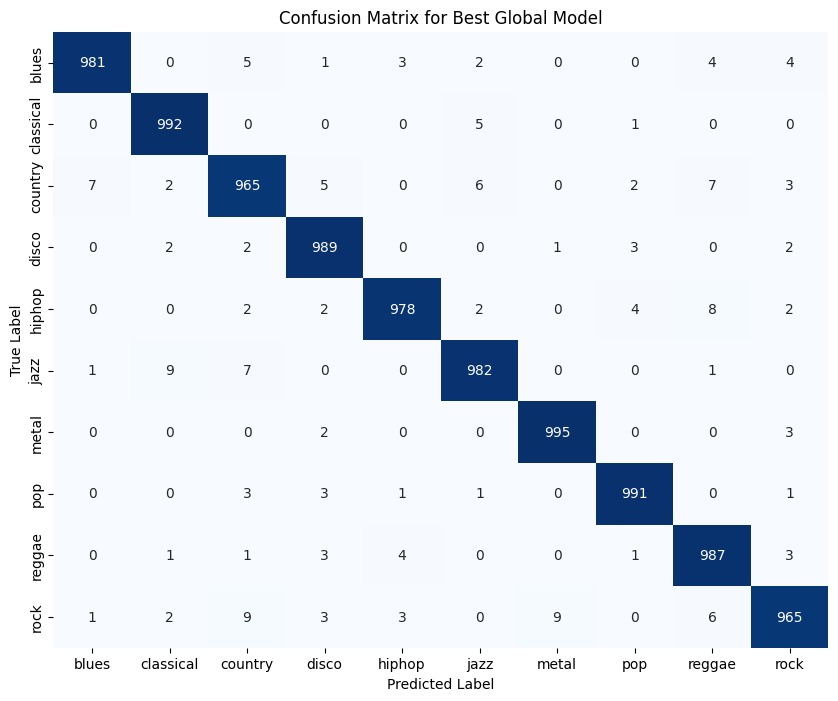

array(['blues', 'blues', 'blues', ..., 'rock', 'rock', 'rock'],
      dtype=object)

In [ ]:
analyze_best_model(pipeline, cap_outliers_iqr(X_3), y_3, y_3_classes)